### Cantilever characterisation

Saved dataset is in folder - `Waveforms/DATASET_02`

Pre-requisites for successfull compilation of the below code is that only one excitation is to be recorded during the entire waveform extracted by Picoscope. The code is not completely re-usable as the FFT is only analysed after 3.26 seconds.

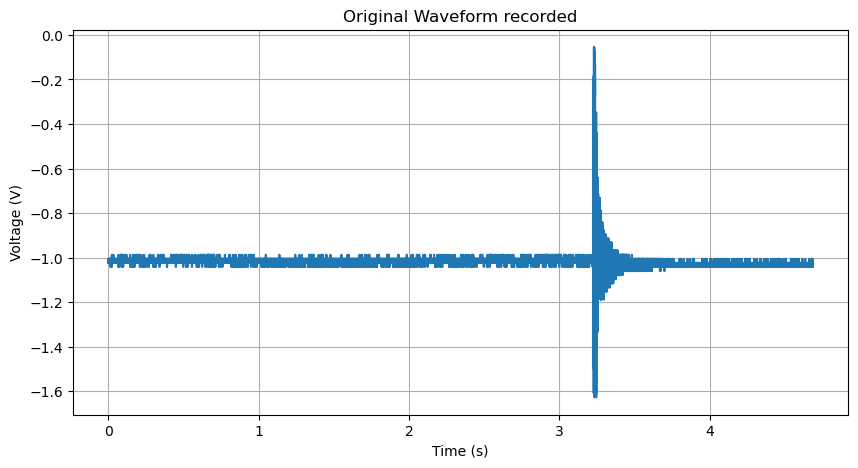

In [45]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks

# Load the CSV file
filepath = 'Waveforms/DATASET_02/TEST3_20_JULY_1533.csv'

# Load the data, skipping the second row which contains units
df = pd.read_csv(filepath, skiprows=[1])

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(df.iloc[:, 0], df.iloc[:, 1])
plt.title("Original Waveform recorded")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

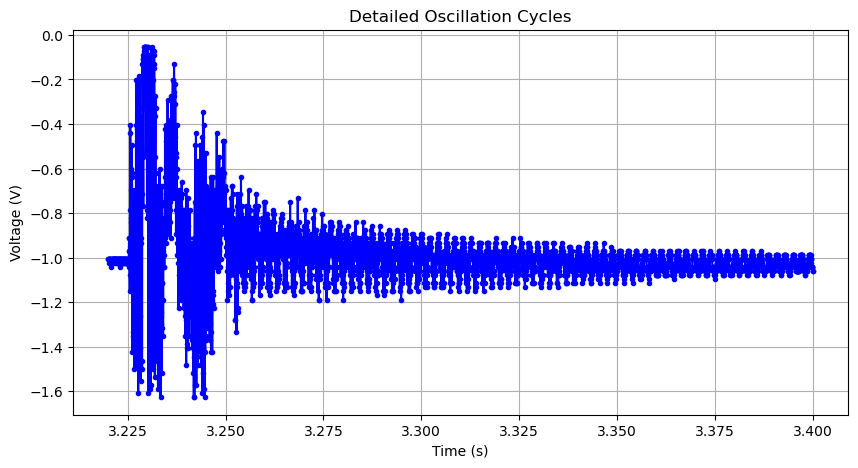

In [46]:
# Extract the actual trigger
df_cycles = df[(df['Time'] >= 3.22) & (df['Time'] <= 3.4)]

plt.figure(figsize=(10, 5))
plt.plot(df_cycles['Time'], df_cycles['Channel A'], 'b.-')
plt.title("Detailed Oscillation Cycles")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

Offset value: -1.0185193636552632
Peak frequency from FFT: 473.68421052741974 Hz


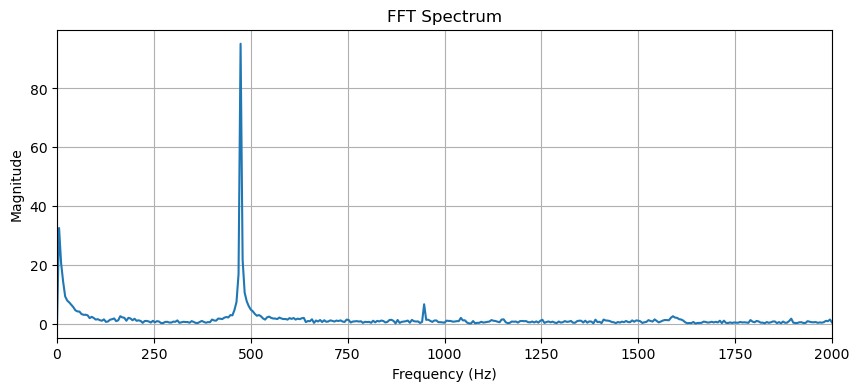

In [47]:
# Apply FFT to the extracted cycles to an interval of 'Pure unforced free vibration' (3.26 to 3.45 seconds)
df_fft = df[(df['Time'] >= 3.26) & (df['Time'] <= 3.45)]

# Sampling interval dt
dt = df_fft['Time'].iloc[1] - df_fft['Time'].iloc[0]
fs = 1.0 / dt

# Removing the offset value from the signal which centers the oscillation to zero
y = df_fft['Channel A'].values - np.mean(df_fft['Channel A'].values)
print(f"Offset value: {np.mean(df_fft['Channel A'].values)}")  # check console for result

# FFT
# Calculates real FFT -> bacause the voltage signal is real valued.
# THen it calculates the corresponding frequencies for the FFT output based on sampling interval calculated above.
n = len(y)
yf = np.fft.rfft(y)
xf = np.fft.rfftfreq(n, d=dt)

# Peak frequency calculation
peak_idx = np.argmax(np.abs(yf)) #abs method calculates the magnitude of the complex FFT output, 
# and np.argmax finds the index of the maximum value in that array.
peak_freq = xf[peak_idx]
print(f"Peak frequency from FFT: {peak_freq} Hz")

plt.figure(figsize=(10, 4))
plt.plot(xf, np.abs(yf))
plt.title("FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 2000)
plt.grid(True)
plt.show()

Offset value: -1.01628632690625


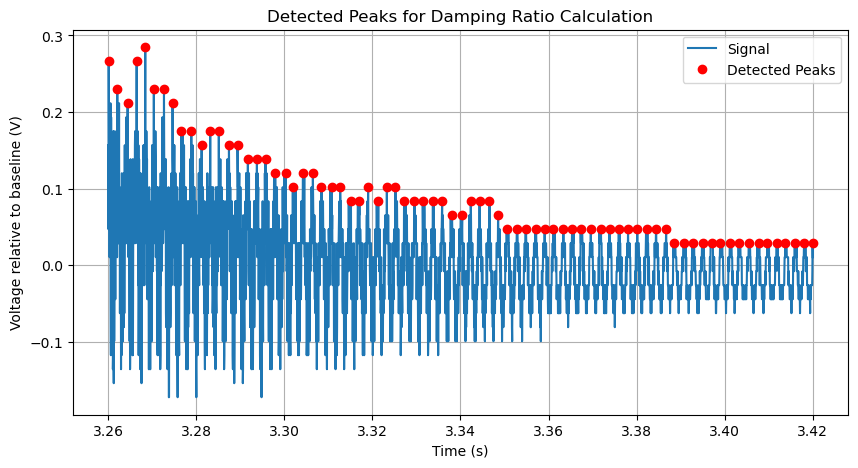

In [ ]:
# Calculation of damping ratio using logarithmic decrement method
df_peaks = df[(df['Time'] >= 3.26) & (df['Time'] <= 3.42)].copy()
time = df_peaks['Time'].values
val = df_peaks['Channel A'].values

baseline = np.mean(val)  # Calculate the mean of the signal to use as a baseline
val_detrend = val - baseline

print(f"Offset value: {baseline}")  # check console for result

# Three params - value with offset removed, min distance between peaks min to avoid false peaks, 
# and prominence of peaks (min value for it to be counted as a peak).
peaks, _ = find_peaks(val_detrend, distance=int(fs/600), prominence=0.005)

peak_times = time[peaks]
peak_vals = val_detrend[peaks]

plt.figure(figsize=(10, 5))
plt.plot(time, val_detrend, label='Signal')
plt.plot(peak_times, peak_vals, 'ro', label='Detected Peaks')
plt.title("Detected Peaks for Damping Ratio Calculation")
plt.xlabel("Time (s)")
plt.ylabel("Voltage relative to baseline (V)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
fd = peak_freq
wd = 2 * np.pi * fd

fit_mask = peak_vals > 0.002 # filter noise
fit_times = peak_times[fit_mask]
fit_log_vals = np.log(peak_vals[fit_mask])

slope, intercept = np.polyfit(fit_times - fit_times[0], fit_log_vals, 1)

decay_constant = -slope
zeta = decay_constant / np.sqrt(wd**2 + decay_constant**2)
fn = fd / np.sqrt(1 - zeta**2)

print(f"Decay constant (sigma): {decay_constant}")
print(f"Damping ratio (zeta): {zeta}")
print(f"Natural Frequency (fn): {fn} Hz")

# zeta is the damping ratio

Decay constant (sigma): 14.456005284770155
Damping ratio (zeta): 0.004857070403771692
Natural Frequency (fn): 473.6897979998643 Hz
